# Transjakarta Demand & Service Analysis

**Stakeholder (framing):** Transjakarta Operations & Planning Division

**Objective:** Analyze passenger transaction data to understand demand patterns across
corridors and time periods, identify potential capacity pressure and service-access
disparities, detect data-completeness anomalies, and produce evidence-based
recommendations for service planning.

**⚠️ Data disclosure:** Transaction records in this dataset are synthetically generated
(Faker library) over Transjakarta's real corridor/route/stop structure. Route geography
is real; individual passenger transactions are not. Findings below demonstrate analytical
methodology on realistic-shaped data, not verified operational conditions. This is stated
explicitly in the README and dashboard as well.

**Success criteria:** 3–5 evidence-backed findings translated into 2–3 actionable
recommendations, each clearly distinguishing what the data directly shows vs. what would
need real operational data (bus counts, headways, fare revenue) to validate.


## 1. Setup

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 5)

con = duckdb.connect(database=':memory:')


## 2. Load data

In [2]:
con.execute("""
    CREATE OR REPLACE TABLE raw_transactions AS
    SELECT * FROM read_csv_auto('Transjakarta.csv')
""")

con.execute("SELECT COUNT(*) AS n_rows FROM raw_transactions").df()


,n_rows
0,37900


In [3]:
con.execute("DESCRIBE raw_transactions").df()


,column_name,column_type,null,key,default,extra
0,transID,VARCHAR,YES,None,None,None
1,payCardID,VARCHAR,YES,None,None,None
2,payCardBank,VARCHAR,YES,None,None,None
3,payCardName,VARCHAR,YES,None,None,None
4,payCardSex,VARCHAR,YES,None,None,None
5,payCardBirthDate,BIGINT,YES,None,None,None
6,corridorID,VARCHAR,YES,None,None,None
7,corridorName,VARCHAR,YES,None,None,None
8,direction,DOUBLE,YES,None,None,None
9,tapInStops,VARCHAR,YES,None,None,None


## 3. Data understanding

Quick pass before cleaning: row count, date coverage, and missingness by column,
so cleaning decisions are based on actual data shape rather than assumption.


In [4]:
schema = con.execute("PRAGMA table_info('raw_transactions')").df()
cols = schema['name'].tolist()

missing_expr = ", ".join([f"ROUND(100.0 * SUM(CASE WHEN \"{c}\" IS NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS \"{c}\"" for c in cols])
missing_pct = con.execute(f"SELECT {missing_expr} FROM raw_transactions").df().T
missing_pct.columns = ['pct_missing']
missing_pct.sort_values('pct_missing', ascending=False)


,pct_missing
tapOutStops,6.04
corridorName,5.09
tapOutStopsLat,3.55
stopEndSeq,3.55
tapOutTime,3.55
tapOutStopsLon,3.55
tapOutStopsName,3.55
corridorID,3.32
tapInStops,3.20
payAmount,2.66


In [5]:
con.execute("""
    SELECT MIN(tapInTime) AS earliest_tap_in, MAX(tapInTime) AS latest_tap_in
    FROM raw_transactions
""").df()


,earliest_tap_in,latest_tap_in
0,2023-04-01 06:22:27,2023-04-30 21:55:41


## 4. Cleaning & feature engineering

- Parse timestamps
- Derive trip duration (minutes)
- Derive passenger age from birth year
- Flag peak hours (morning 05:00–09:00, evening 16:00–21:00, based on known TJ ridership patterns)
- Flag weekday vs weekend
- Flag incomplete records (missing tap-out / corridor / stop) as a **data-completeness**
  signal rather than searching for duration outliers (duration field is artificially
  bounded 15–180 min in this dataset, see disclosure above, no organic outliers exist)


In [6]:
df = con.execute("SELECT * FROM raw_transactions").df()

df['tapInTime'] = pd.to_datetime(df['tapInTime'], errors='coerce')
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'], errors='coerce')

df['trip_duration_min'] = (df['tapOutTime'] - df['tapInTime']).dt.total_seconds() / 60
df['tap_in_hour'] = df['tapInTime'].dt.hour
df['tap_in_date'] = df['tapInTime'].dt.date
df['day_of_week'] = df['tapInTime'].dt.day_name()
df['is_weekend'] = df['tapInTime'].dt.dayofweek >= 5

df['passenger_age'] = 2023 - df['payCardBirthDate']

def age_group(age):
    if pd.isna(age):
        return 'Unknown'
    if age < 20:
        return 'Youth (<20)'
    if age < 60:
        return 'Adult (20-59)'
    return 'Senior (60+)'

df['age_group'] = df['passenger_age'].apply(age_group)

def peak_flag(hour):
    if pd.isna(hour):
        return 'Unknown'
    if 5 <= hour <= 9:
        return 'Morning Peak'
    if 16 <= hour <= 21:
        return 'Evening Peak'
    return 'Off-Peak'

df['peak_period'] = df['tap_in_hour'].apply(peak_flag)

df['is_incomplete_record'] = (
    df['tapOutStops'].isna() | df['corridorName'].isna() | df['tapOutTime'].isna()
)

con.register('df_clean', df)
con.execute("CREATE OR REPLACE TABLE transactions AS SELECT * FROM df_clean")

df[['trip_duration_min', 'passenger_age', 'age_group', 'peak_period', 'is_incomplete_record']].describe(include='all')


,trip_duration_min,passenger_age,age_group,peak_period,is_incomplete_record
count,36556.000000,37900.000000,37900,37900,37900
unique,NaN,NaN,3,3,2
top,NaN,NaN,Adult (20-59),Evening Peak,False
freq,NaN,NaN,30089,18292,33805
mean,72.125424,32.910686,NaN,NaN,NaN
std,28.072912,13.051482,NaN,NaN,NaN
min,15.000000,11.000000,NaN,NaN,NaN
25%,51.133333,22.000000,NaN,NaN,NaN
50%,71.833333,33.000000,NaN,NaN,NaN
75%,95.800000,41.000000,NaN,NaN,NaN


---
## 5. Demand patterns
*Q1–Q4: Where/when is demand highest, trend over the month, capacity-pressure signals, weekday vs weekend*


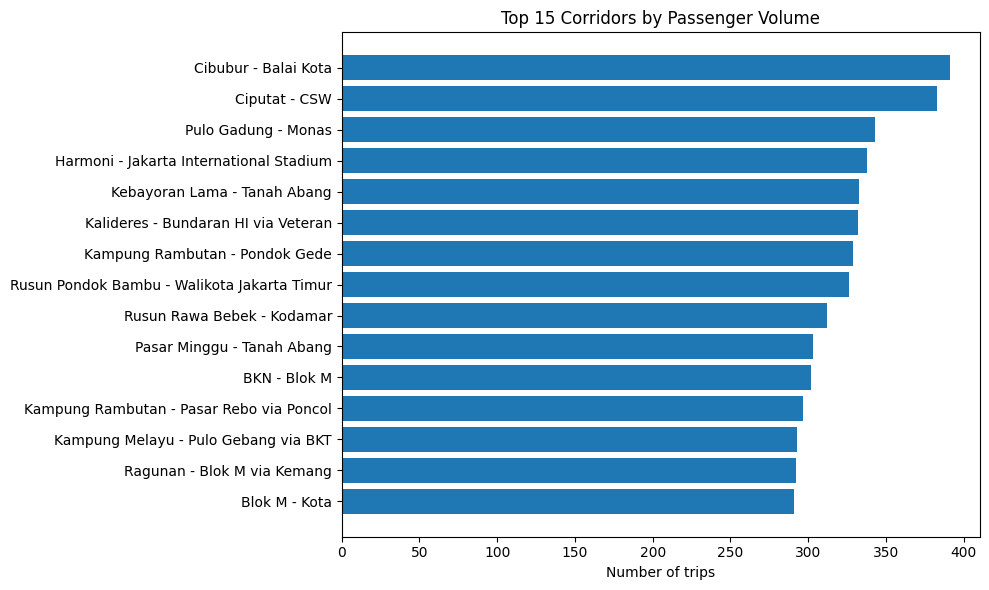

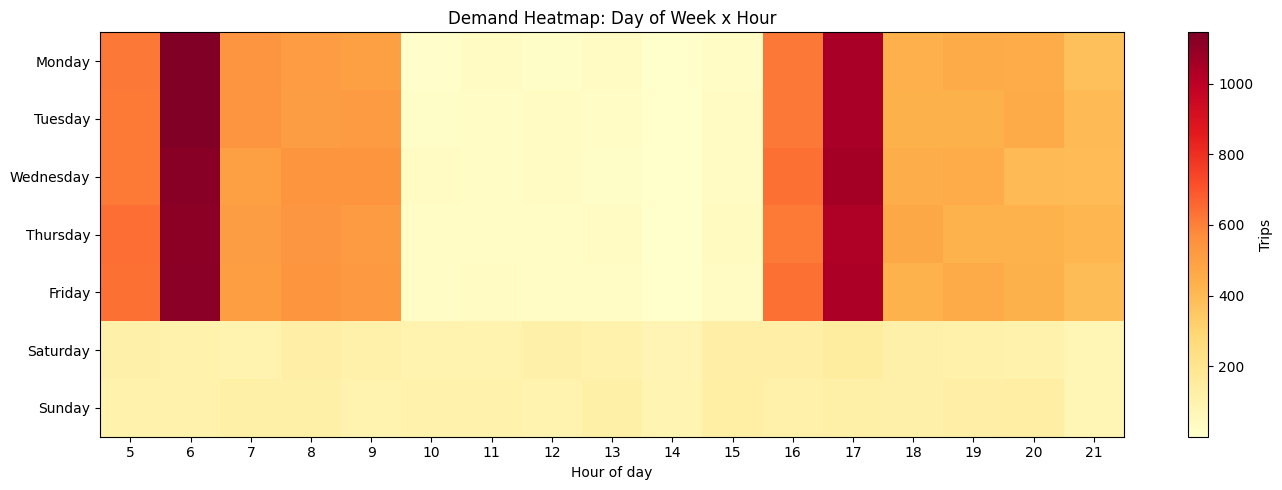

In [7]:
# Q1: demand by corridor, day of week, hour
# Top corridors by transaction volume
top_corridors = con.execute("""
    SELECT corridorName, COUNT(*) AS n_trips
    FROM transactions
    WHERE corridorName IS NOT NULL
    GROUP BY corridorName
    ORDER BY n_trips DESC
    LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(top_corridors['corridorName'][::-1], top_corridors['n_trips'][::-1])
ax.set_title('Top 15 Corridors by Passenger Volume')
ax.set_xlabel('Number of trips')
plt.tight_layout()
plt.show()

# Day-of-week x hour heatmap
heat = df.pivot_table(index='day_of_week', columns='tap_in_hour', values='transID', aggfunc='count')
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat = heat.reindex(day_order)

fig, ax = plt.subplots(figsize=(14,5))
im = ax.imshow(heat, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns)
ax.set_xlabel('Hour of day'); ax.set_title('Demand Heatmap: Day of Week x Hour')
plt.colorbar(im, label='Trips')
plt.tight_layout()
plt.show()

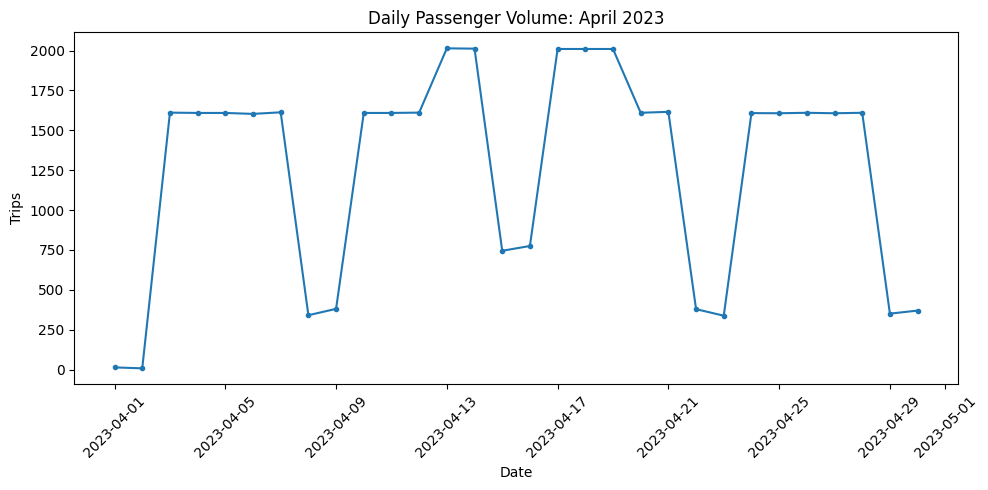

In [8]:
# Q2: demand trend over the observed period (daily volume line chart)
daily = df.groupby('tap_in_date').size().reset_index(name='n_trips')

fig, ax = plt.subplots()
ax.plot(daily['tap_in_date'], daily['n_trips'], marker='o', markersize=3)
ax.set_title('Daily Passenger Volume: April 2023')
ax.set_ylabel('Trips'); ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Q3: corridors with demand concentration that may indicate capacity pressure (top-N + distribution shape)
corridor_daily = df.groupby(['corridorName', 'tap_in_date']).size().reset_index(name='n_trips')
corridor_stats = corridor_daily.groupby('corridorName')['n_trips'].agg(['mean','std','max']).reset_index()
corridor_stats['cv'] = corridor_stats['std'] / corridor_stats['mean']  # coefficient of variation
corridor_stats = corridor_stats.sort_values('mean', ascending=False).head(15)

print("Note: 'capacity pressure' here means sustained high demand volume,")
print("not confirmed overcrowding, no bus-count/headway data available to verify actual capacity.")
corridor_stats

Note: 'capacity pressure' here means sustained high demand volume,
not confirmed overcrowding, no bus-count/headway data available to verify actual capacity.


,corridorName,mean,std,max,cv
21,Cibubur - Balai Kota,14.481481,8.006586,20,0.552884
33,Ciputat - CSW,13.206897,7.330851,20,0.555078
116,Pulo Gadung - Monas,13.192308,5.359248,18,0.406240
77,Kebayoran Lama - Tanah Abang,12.807692,5.926343,17,0.462717
73,Kampung Rambutan - Pondok Gede,12.653846,5.939308,18,0.469368
157,Rusun Pondok Bambu - Walikota Jakarta Timur,12.074074,6.050594,17,0.501123
55,Kalideres - Bundaran HI via Veteran,11.857143,5.475293,21,0.461772
47,Harmoni - Jakarta International Stadium,11.655172,6.376720,18,0.547115
1,BKN - Blok M,11.615385,5.192895,18,0.447070
159,Rusun Rawa Bebek - Kodamar,11.555556,5.351731,18,0.463131


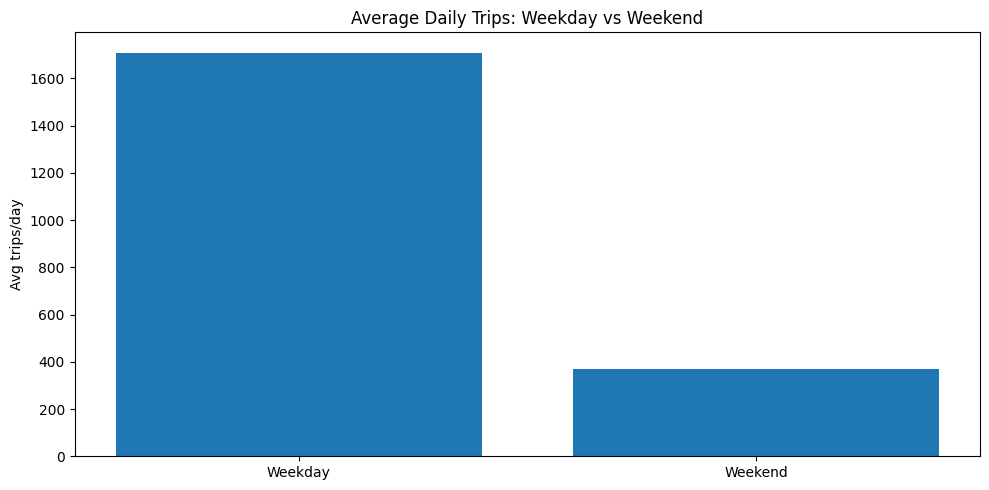

In [10]:
# Q4: weekday vs weekend demand comparison
wk_comparison = df.groupby('is_weekend').size().reset_index(name='n_trips')
wk_comparison['label'] = wk_comparison['is_weekend'].map({True: 'Weekend', False: 'Weekday'})
wk_comparison['avg_daily'] = wk_comparison['n_trips'] / df.groupby('is_weekend')['tap_in_date'].nunique().values

fig, ax = plt.subplots()
ax.bar(wk_comparison['label'], wk_comparison['avg_daily'])
ax.set_title('Average Daily Trips: Weekday vs Weekend')
ax.set_ylabel('Avg trips/day')
plt.tight_layout()
plt.show()

## 6. Service & access
*Q5–Q8: trip duration variation, geographic access gaps, payment-method patterns, demographic usage patterns*


              mean  median   std
peak_period                     
Evening Peak  83.8    84.0  21.5
Morning Peak  60.1    53.3  28.6
Off-Peak      71.9    70.4  31.2


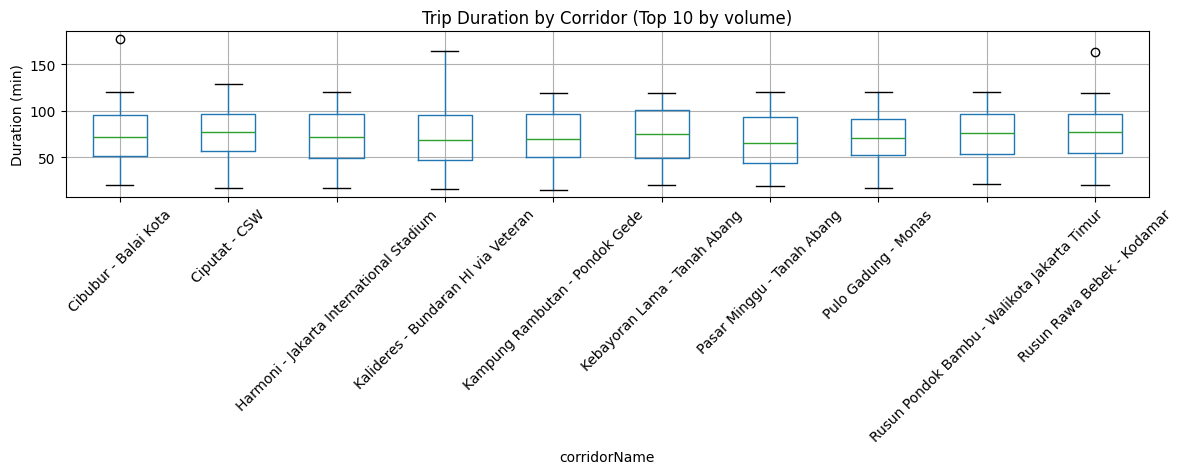

In [11]:
# Q5: trip duration by corridor / stop / time of day
duration_by_peak = df.groupby('peak_period')['trip_duration_min'].agg(['mean','median','std']).round(1)
print(duration_by_peak)

top10_corridors = df['corridorName'].value_counts().head(10).index
fig, ax = plt.subplots(figsize=(12,5))
df[df['corridorName'].isin(top10_corridors)].boxplot(column='trip_duration_min', by='corridorName', ax=ax, rot=45)
ax.set_title('Trip Duration by Corridor (Top 10 by volume)')
plt.suptitle('')
ax.set_ylabel('Duration (min)')
plt.tight_layout()
plt.show()

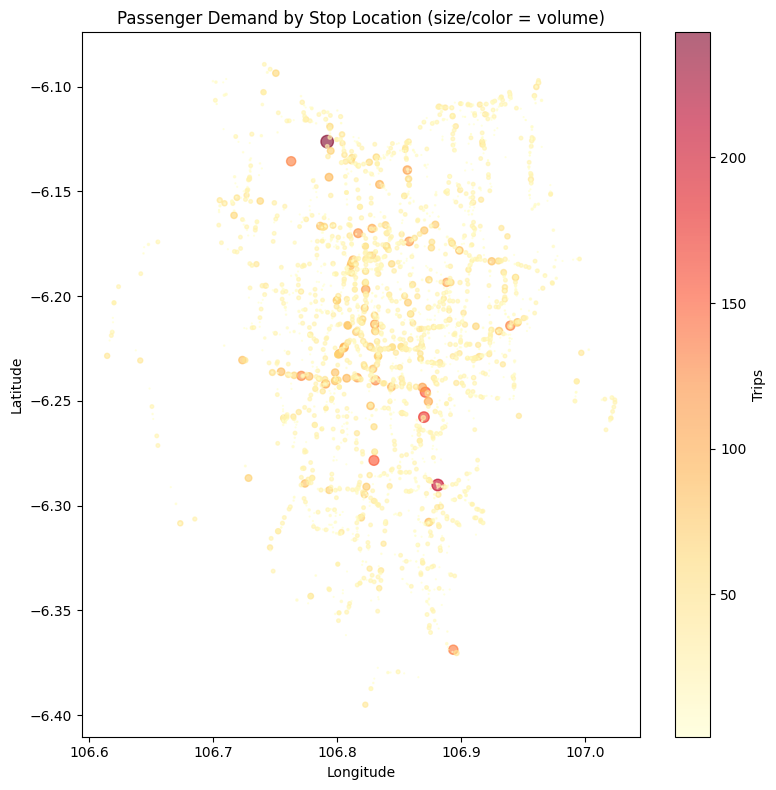

,tapInStopsName,tapInStopsLat,tapInStopsLon,n_trips
1291,Penjaringan,-6.126306,106.792030,243
273,Garuda Taman Mini,-6.290154,106.881160,208
52,BKN,-6.257751,106.870000,173
58,BNN LRT,-6.245863,106.871143,155
1272,Pejaten,-6.278404,106.829720,152
165,Cibubur Junction,-6.368735,106.893660,133
1612,Rusun Kapuk Muara,-6.135667,106.762990,131
1288,Penggilingan,-6.214132,106.939610,130
2495,Tendean,-6.240213,106.831020,126
2194,Seskoal,-6.238064,106.771210,126


In [12]:
# Q6: geographic demand map (corridor/stop coordinates), flagged for later cross-check against population density
stop_demand = df.groupby(['tapInStopsName','tapInStopsLat','tapInStopsLon']).size().reset_index(name='n_trips')
stop_demand = stop_demand.sort_values('n_trips', ascending=False)

fig, ax = plt.subplots(figsize=(8,8))
sc = ax.scatter(stop_demand['tapInStopsLon'], stop_demand['tapInStopsLat'],
                 s=stop_demand['n_trips']/3, c=stop_demand['n_trips'], cmap='YlOrRd', alpha=0.6)
ax.set_title('Passenger Demand by Stop Location (size/color = volume)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.colorbar(sc, label='Trips')
plt.tight_layout()
plt.show()

# NOTE: comparing this against real population density requires external BPS
# kelurahan-level data, not included here. Treat as usage concentration only,
# not a verified "underserved area" finding.
stop_demand.head(10)

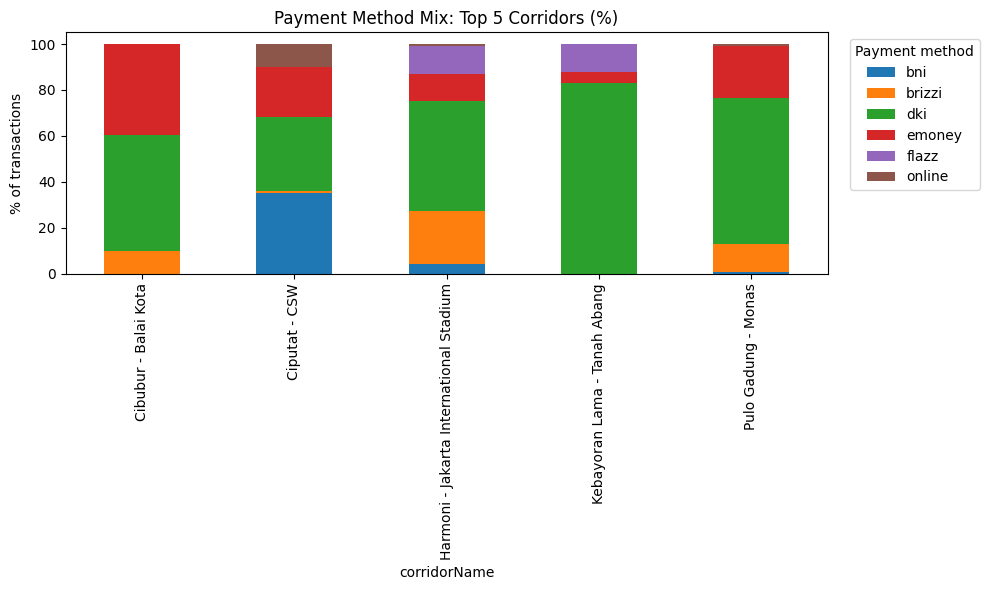

In [13]:
# Q7: payment method (payCardBank) mix by corridor
top5_corridors = df['corridorName'].value_counts().head(5).index
pay_mix = pd.crosstab(df[df['corridorName'].isin(top5_corridors)]['corridorName'],
                       df[df['corridorName'].isin(top5_corridors)]['payCardBank'],
                       normalize='index').round(3) * 100

pay_mix.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Payment Method Mix: Top 5 Corridors (%)')
plt.ylabel('% of transactions')
plt.legend(title='Payment method', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

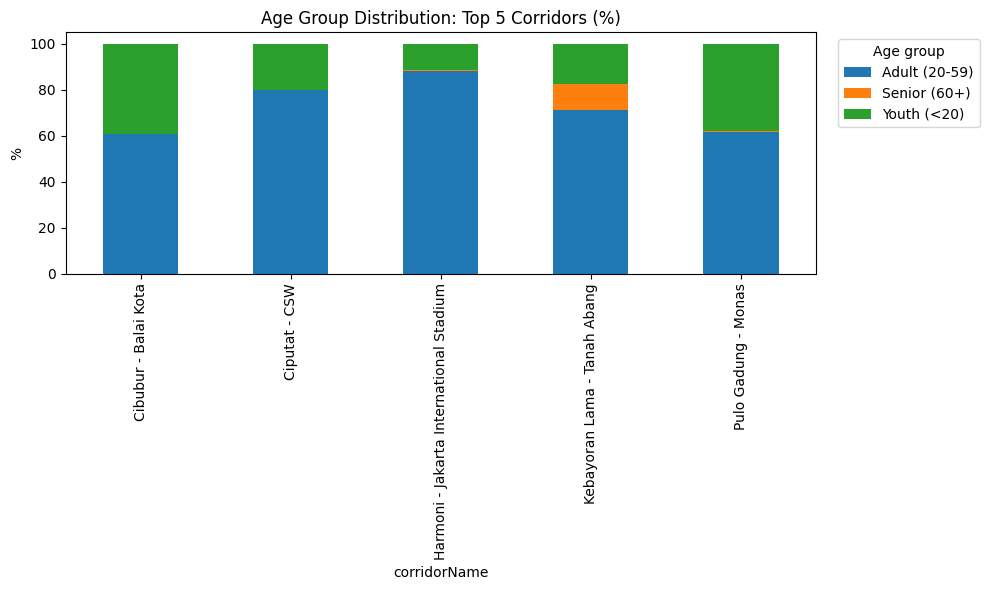

payCardSex,F,M
corridorName,,
Cibubur - Balai Kota,40.7,59.3
Ciputat - CSW,32.9,67.1
Harmoni - Jakarta International Stadium,37.6,62.4
Kebayoran Lama - Tanah Abang,52.3,47.7
Pulo Gadung - Monas,51.3,48.7


In [14]:
# Q8: age_group / gender usage patterns by corridor
demo_by_corridor = df[df['corridorName'].isin(top5_corridors)].groupby(
    ['corridorName', 'age_group']).size().unstack(fill_value=0)
demo_pct = demo_by_corridor.div(demo_by_corridor.sum(axis=1), axis=0) * 100

demo_pct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Age Group Distribution: Top 5 Corridors (%)')
plt.ylabel('%'); plt.legend(title='Age group', bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

gender_by_corridor = pd.crosstab(df[df['corridorName'].isin(top5_corridors)]['corridorName'],
                                   df[df['corridorName'].isin(top5_corridors)]['payCardSex'],
                                   normalize='index').round(3) * 100
gender_by_corridor

## 7. Data quality / completeness
*Q9–Q10: incomplete-record patterns as an operational signal, not duration-outlier detection*


In [15]:
# Q9: incomplete record rate by corridor / stop / time period
incomplete_by_corridor = df.groupby('corridorName')['is_incomplete_record'].agg(['sum','count','mean']).reset_index()
incomplete_by_corridor.columns = ['corridorName','n_incomplete','n_total','incomplete_rate']
incomplete_by_corridor = incomplete_by_corridor[incomplete_by_corridor['n_total'] >= 30]  # filter low-volume noise
incomplete_by_corridor.sort_values('incomplete_rate', ascending=False).head(15)

,corridorName,n_incomplete,n_total,incomplete_rate
80,Kp. Rambutan - Taman Wiladatika,9,82,0.109756
144,Rusun Cipinang Besar Selatan - Penas Kalimalang,15,138,0.108696
65,Kampung Melayu - Tanah Abang via Cikini,18,171,0.105263
184,Sunter Boulevard Barat - Penjaringan,10,96,0.104167
179,Stasiun Tebet - Kampung Melayu,16,157,0.101911
117,Pulo Gadung - Rawa Buaya via Balai Kota,14,141,0.099291
45,Harapan Baru - Pulo Gebang via Rawa Kuning,13,132,0.098485
152,Rusun Marunda - Tanjung Priok,14,143,0.097902
172,Senen - Tanah Abang,4,41,0.097561
170,Senen - Pulo Gadung,11,118,0.093220


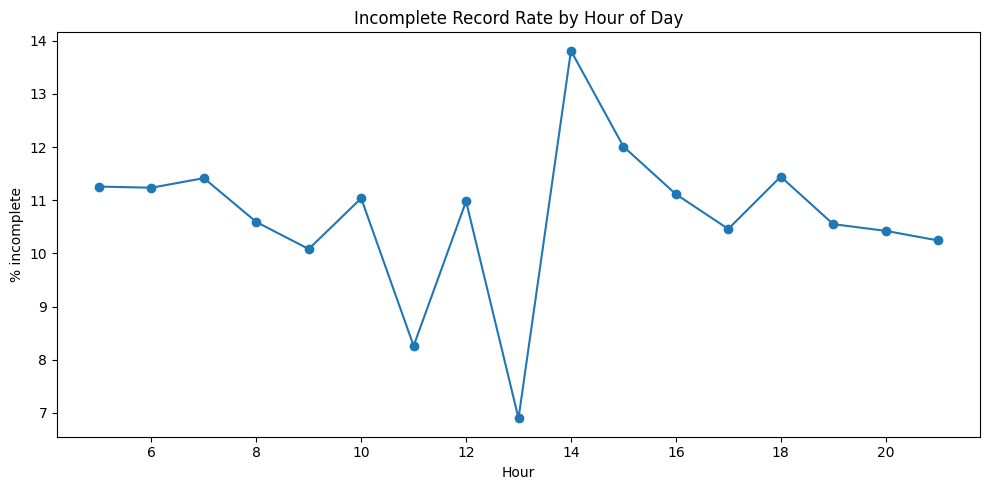

day_of_week
Monday       11.319099
Tuesday      10.124360
Wednesday    11.198830
Thursday     10.842845
Friday       10.348854
Saturday     10.710383
Sunday       11.591880
Name: is_incomplete_record, dtype: float64

In [16]:
# Q10: are incomplete records concentrated in specific corridors or time windows (potential tap system reliability signal)?
incomplete_by_hour = df.groupby('tap_in_hour')['is_incomplete_record'].mean() * 100

fig, ax = plt.subplots()
ax.plot(incomplete_by_hour.index, incomplete_by_hour.values, marker='o')
ax.set_title('Incomplete Record Rate by Hour of Day')
ax.set_xlabel('Hour'); ax.set_ylabel('% incomplete')
plt.tight_layout()
plt.show()

incomplete_by_day = df.groupby('day_of_week')['is_incomplete_record'].mean().reindex(day_order) * 100
incomplete_by_day

## 8. Recommendations
*Q11–Q12: proposed service adjustments + what would need real operational data to validate; which findings are actionable vs. hypotheses*


In [17]:
# Q11 / Q12: synthesize findings above into 2-3 recommendations with explicit validation caveats
# Pull the concrete numbers you'll need for the write-up
print("Top corridor by volume:", top_corridors.iloc[0]['corridorName'], "-", top_corridors.iloc[0]['n_trips'], "trips")
print("Weekday vs weekend avg daily trips:")
print(wk_comparison[['label','avg_daily']])
print("\nHighest incomplete-record corridor:")
print(incomplete_by_corridor.sort_values('incomplete_rate', ascending=False).head(3))

Top corridor by volume: Cibubur - Balai Kota - 391 trips
Weekday vs weekend avg daily trips:
     label  avg_daily
0  Weekday     1709.9
1  Weekend      370.2

Highest incomplete-record corridor:
                                        corridorName  n_incomplete  n_total  \
80                   Kp. Rambutan - Taman Wiladatika             9       82   
144  Rusun Cipinang Besar Selatan - Penas Kalimalang            15      138   
65           Kampung Melayu - Tanah Abang via Cikini            18      171   

     incomplete_rate  
80          0.109756  
144         0.108696  
65          0.105263  
